# Set-Up

In [7]:
# Install packages

!pip install "laspy[lazrs]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 638.7/638.7 kB 11.9 MB/s  0:00:00


In [ ]:
# Import packages

import pandas as pd
import os
import glob
import numpy as np
import laspy
from laspy import LazBackend
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
import json
import collections
import requests
from rasterio.warp import transform_bounds
from rasterio.merge import merge
import xml.etree.ElementTree as ET
from shapely.geometry import box
from shapely.ops import unary_union, transform as shp_transform
from shapely import wkt as shp_wkt
from shapely.geometry import box as shp_box
from pyproj import Transformer
from urllib.parse import quote
import rasterio
from rasterio.windows import Window, from_bounds
from rasterio.transform import from_origin
import zipfile

In [2]:
# Set directories

old_data_dir = '/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/pondinlet_lidar'
new_data_dir_cam = '/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/cambridge_lidar'
new_data_dir_tuk = '/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_lidar'

# Exploration

In [3]:
# Load in cambridge sample 

path = os.path.join(new_data_dir_cam, "FULL_ALS_L1B_20240418T203153_203450_detrended.copc.laz")
las = laspy.read(path, laz_backend=LazBackend.Lazrs)

In [4]:
# Get Cambridge sample details

# Summary information
print(las.header.version, las.header.point_format)
print("count:", len(las.points))
print("scale:", las.header.scales, "offset:", las.header.offsets)
print("xyz ranges:", (las.x.min(), las.x.max()),
                      (las.y.min(), las.y.max()),
                      (las.z.min(), las.z.max()))
print("SRS WKT present?", bool(las.header.parse_crs()))

# Density estimate
area_m2 = (las.x.max() - las.x.min()) * (las.y.max() - las.y.min())
density = len(las.points) / area_m2 if area_m2 > 0 else float("nan")
print("approx density (pts/m^2):", density)


1.4 <PointFormat(6, 0 bytes of extra dims)>
count: 3123149
scale: [0.01 0.01 0.01] offset: [0. 0. 0.]
xyz ranges: (np.float64(466603.09), np.float64(474158.56)) (np.float64(7652097.16), np.float64(7657257.18)) (np.float64(-0.31), np.float64(1.86))
SRS WKT present? True
approx density (pts/m^2): 0.08010872760306426


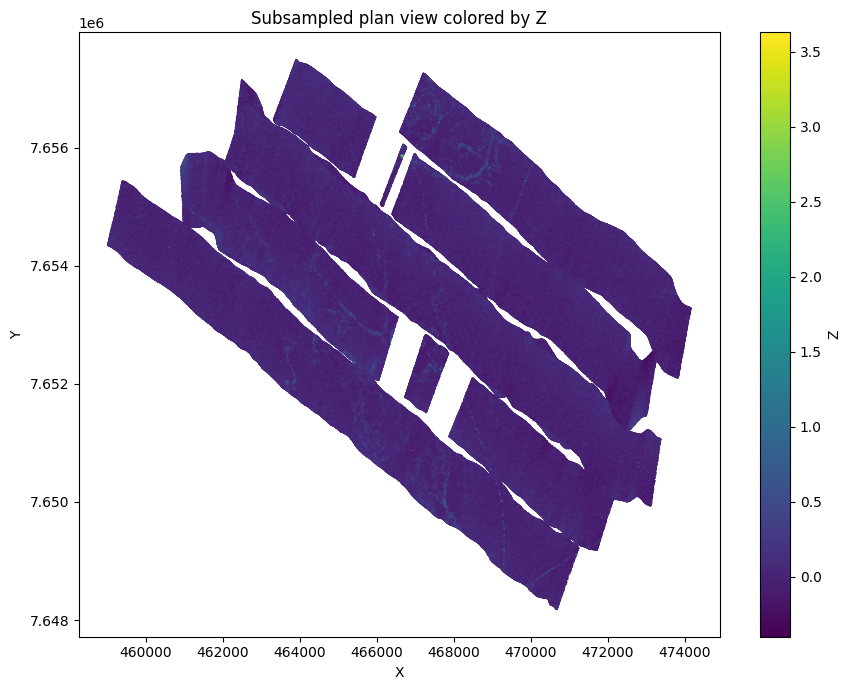

Mean LiDAR value: 0.0385248
Min LiDAR value: -0.4
Max LiDAR value: 3.63


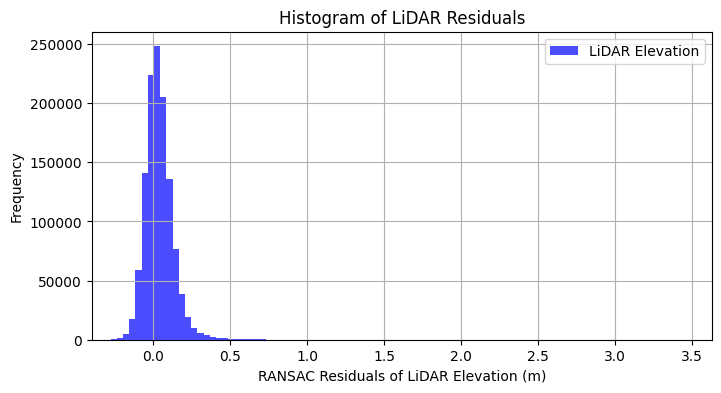

In [6]:
# Visualize Cambridge data

# Load in data
files = sorted(glob.glob(os.path.join(new_data_dir_cam, "*.laz")))

# Subsample for plotting
points_per_file = 200_000
use_backend = LazBackend.Lazrs 

xs, ys, zs = [], [], []

for fp in files:
    las = laspy.read(fp, laz_backend=use_backend)
    x, y, z = las.x, las.y, las.z
    n = len(x)
    if n == 0:
        continue
    # Subsample
    keep = min(points_per_file, n)
    idx = np.random.choice(n, size=keep, replace=False)
    xs.append(x[idx]); ys.append(y[idx]); zs.append(z[idx])

X = np.concatenate(xs) if xs else np.array([])
Y = np.concatenate(ys) if ys else np.array([])
Z = np.concatenate(zs) if zs else np.array([])

if X.size == 0:
    raise SystemExit("No points loaded.")

# Scatterplot 
plt.figure(figsize=(9,7))
plt.scatter(X, Y, c=Z, s=0.2)
plt.title("Subsampled plan view colored by Z")
plt.xlabel("X"); plt.ylabel("Y")
plt.colorbar(label="Z")
plt.tight_layout()
plt.show()

# Set Z as lidar_array
lidar_array = Z

# Replace -9999 with NaN
lidar_array = np.where(lidar_array == -9999, np.nan, lidar_array)

# Get min and max LiDAR values
lidar_min = np.nanmin(lidar_array)
lidar_max = np.nanmax(lidar_array)
lidar_mean = np.nanmean(lidar_array)
print(f"Mean LiDAR value: {lidar_mean}")
print(f"Min LiDAR value: {lidar_min}")
print(f"Max LiDAR value: {lidar_max}")

# Get histogram of LiDAR values
plt.figure(figsize=(8, 4))
plt.hist(lidar_array[~np.isnan(lidar_array)].flatten(), bins=100,
            color='blue', alpha=0.7, label='LiDAR Elevation')
plt.ticklabel_format(style='plain', axis='y')
plt.title("Histogram of LiDAR Residuals")
plt.xlabel("RANSAC Residuals of LiDAR Elevation (m)")
plt.ylabel("Frequency")
plt.xlim(lidar_min, lidar_max)
plt.legend()
plt.grid()
plt.show()

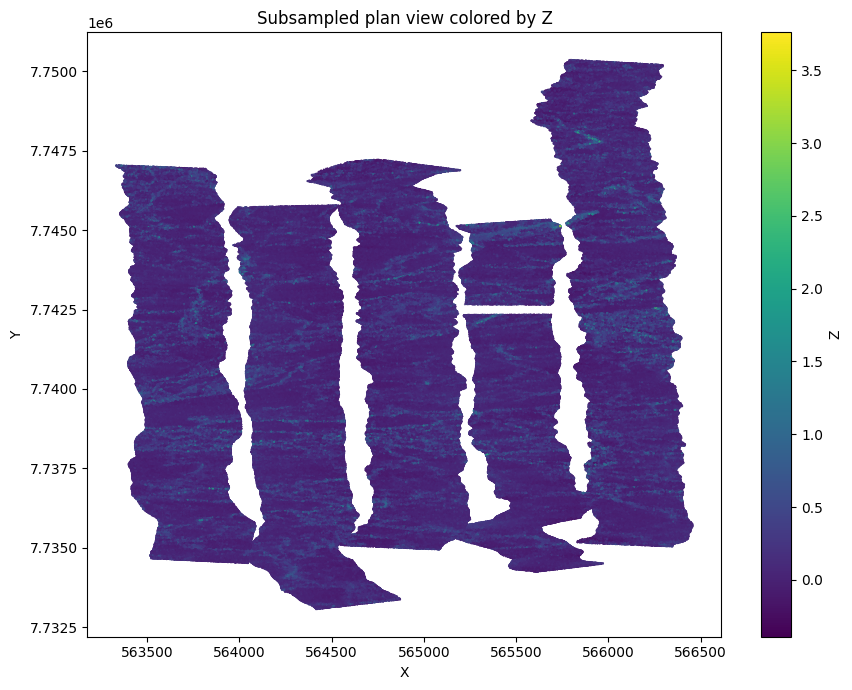

Mean LiDAR value: 0.13384882999999997
Min LiDAR value: -0.39
Max LiDAR value: 3.7600000000000002


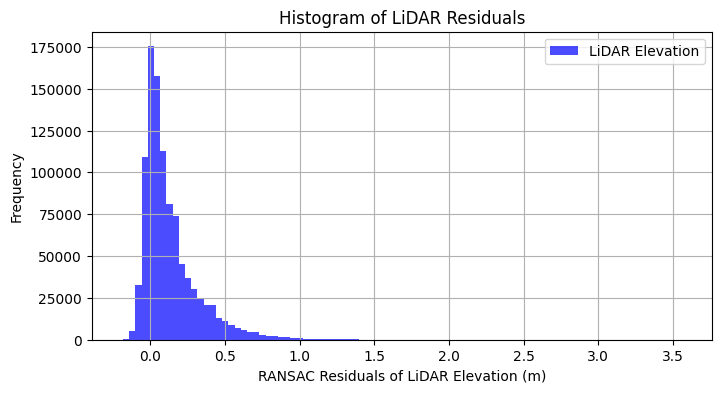

In [7]:
# Visualize tuk data

# Load in data
files = sorted(glob.glob(os.path.join(new_data_dir_tuk, "*.laz")))

# Subsample for plotting
points_per_file = 200_000
use_backend = LazBackend.Lazrs 

xs, ys, zs = [], [], []

for fp in files:
    las = laspy.read(fp, laz_backend=use_backend)
    x, y, z = las.x, las.y, las.z
    n = len(x)
    if n == 0:
        continue
    # Subsample
    keep = min(points_per_file, n)
    idx = np.random.choice(n, size=keep, replace=False)
    xs.append(x[idx]); ys.append(y[idx]); zs.append(z[idx])

X = np.concatenate(xs) if xs else np.array([])
Y = np.concatenate(ys) if ys else np.array([])
Z = np.concatenate(zs) if zs else np.array([])

if X.size == 0:
    raise SystemExit("No points loaded.")

# Scatterplot 
plt.figure(figsize=(9,7))
plt.scatter(X, Y, c=Z, s=0.2)
plt.title("Subsampled plan view colored by Z")
plt.xlabel("X"); plt.ylabel("Y")
plt.colorbar(label="Z")
plt.tight_layout()
plt.show()

# Set Z as lidar_array
lidar_array = Z

# Replace -9999 with NaN
lidar_array = np.where(lidar_array == -9999, np.nan, lidar_array)

# Get min and max LiDAR values
lidar_min = np.nanmin(lidar_array)
lidar_max = np.nanmax(lidar_array)
lidar_mean = np.nanmean(lidar_array)
print(f"Mean LiDAR value: {lidar_mean}")
print(f"Min LiDAR value: {lidar_min}")
print(f"Max LiDAR value: {lidar_max}")

# Get histogram of LiDAR values
plt.figure(figsize=(8, 4))
plt.hist(lidar_array[~np.isnan(lidar_array)].flatten(), bins=100,
            color='blue', alpha=0.7, label='LiDAR Elevation')
plt.ticklabel_format(style='plain', axis='y')
plt.title("Histogram of LiDAR Residuals")
plt.xlabel("RANSAC Residuals of LiDAR Elevation (m)")
plt.ylabel("Frequency")
plt.xlim(lidar_min, lidar_max)
plt.legend()
plt.grid()
plt.show()

# Data Conversion

In [ ]:
# Convert LAZ files to GeoTIFF

def laz_to_tif(laz_path, tif_path, resolution=1.0):
    # Load LAZ file
    las = laspy.read(laz_path)
    x, y, z = las.x, las.y, las.z

    # Calculate bounds
    min_x, min_y = x.min(), y.min()
    max_x, max_y = x.max(), y.max()

    width = int(np.ceil((max_x - min_x) / resolution))
    height = int(np.ceil((max_y - min_y) / resolution))

    # Create empty elevation raster
    elevation = np.full((height, width), np.nan)

    # Convert coordinates to raster indices
    col = ((x - min_x) / resolution).astype(int)
    row = ((max_y - y) / resolution).astype(int)

    # Fill in elevation values (use mean if multiple points per cell)
    for r, c, val in zip(row, col, z):
        if np.isnan(elevation[r, c]):
            elevation[r, c] = val
        else:
            elevation[r, c] = (elevation[r, c] + val) / 2

    # Replace NaNs with -9999
    elevation = np.nan_to_num(elevation, nan=-9999)

    # Set transform and crs
    transform = from_origin(min_x, max_y, resolution, resolution)
    crs = las.header.parse_crs() 
    if crs is None:
        raise ValueError("LAZ has no CRS")

    # Save to GeoTIFF
    with rasterio.open(
        tif_path,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype=elevation.dtype,
        crs=crs,
        transform=transform,
    ) as dst:
        dst.write(elevation, 1)

# Loop through LAZ files
for laz_file in os.listdir(new_data_dir_cam):
    if laz_file.endswith('.laz'):
        laz_file = os.path.join(new_data_dir_cam, laz_file)
        tif_file = laz_file.replace('_detrended.copc.laz', '.tif')
        laz_to_tif(laz_file, tif_file)

print("Cambridge conversion complete.")

for laz_file in os.listdir(new_data_dir_tuk):
    if laz_file.endswith('.laz'):
        laz_file = os.path.join(new_data_dir_tuk, laz_file)
        tif_file = laz_file.replace('_detrended.copc.laz', '.tif')
        laz_to_tif(laz_file, tif_file)

print("Tuk conversion complete.")

# Data Collocation

In [ ]:
# Helper functions

# =========================
# Auth + basic HTTP
# =========================
def get_access_and_refresh_token(username, password):
    url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    data = {
        "grant_type": "password",
        "username": username,
        "password": password,
        "client_id": "cdse-public",
    }
    r = requests.post(url, data=data)
    r.raise_for_status()
    js = r.json()
    return js["access_token"], js["refresh_token"]

def refresh_access_token(refresh_token):
    url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    data = {
        "grant_type": "refresh_token",
        "refresh_token": refresh_token,
        "client_id": "cdse-public",
    }
    r = requests.post(url, data=data, headers={"Content-Type": "application/x-www-form-urlencoded"})
    r.raise_for_status()
    return r.json()["access_token"]

def make_api_request(url, method="GET", data=None, headers=None):
    # minimal retry on 401/403 using global tokens
    global access_token, refresh_token
    if not headers:
        headers = {"Authorization": f"Bearer {access_token}"}
    resp = requests.request(method, url, json=data, headers=headers)
    if resp.status_code in (401, 403):
        access_token = refresh_access_token(refresh_token)
        headers["Authorization"] = f"Bearer {access_token}"
        resp = requests.request(method, url, json=data, headers=headers)
    return resp

# =========================
# Geometry helpers (LiDAR bounds -> WKT)
# =========================
def get_combined_bounds(tif_dir):
    geoms = []
    for fname in os.listdir(tif_dir):
        if fname.lower().endswith(".tif"):
            with rasterio.open(os.path.join(tif_dir, fname)) as src:
                b = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
                geoms.append(box(*b))
    return unary_union(geoms)

def bounds_to_wkt(bounds_geom):
    return bounds_geom.wkt


# =========================
# Catalogue query (with cloudCover)
# =========================
def query_sentinel2_for_tif_area(start_date, end_date, token, wkt_polygon, min_cloud=0, max_cloud=20):
    all_rows = []
    filter_string = (
        f"Collection/Name eq 'SENTINEL-2' and "
        f"Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' and att/Value eq 'S2MSI2A') and "
        f"Attributes/OData.CSC.DoubleAttribute/any(att:att/Name eq 'cloudCover' and att/Value ge {min_cloud}) and "
        f"Attributes/OData.CSC.DoubleAttribute/any(att:att/Name eq 'cloudCover' and att/Value le {max_cloud}) and "
        f"ContentDate/Start gt {start_date}T00:00:00.000Z and ContentDate/Start lt {end_date}T23:59:59.999Z"
    )

    next_url = (
        "https://catalogue.dataspace.copernicus.eu/odata/v1/Products?"
        f"$filter={filter_string} and OData.CSC.Intersects(area=geography'SRID=4326;{wkt_polygon}')"
        "&$top=100&$expand=Attributes"
    )
    headers = {"Authorization": f"Bearer {token}"}

    while next_url:
        r = make_api_request(next_url, headers=headers)
        r.raise_for_status()
        js = r.json()
        all_rows.extend(js.get("value", []))
        next_url = js.get("@odata.nextLink")

    return pd.DataFrame(all_rows)

# =========================
# Format results (+ cloud cover column)
# =========================
def format_sentinel2_results(df_raw):
    out = []
    for _, row in df_raw.iterrows():
        cloud_cover = None
        for att in row.get("Attributes", []):
            if att.get("Name") == "cloudCover":
                cloud_cover = att.get("Value")
                break

        cd = row.get("ContentDate", {})
        name = row.get("Name", "")
        out.append({
            "ProductID": row["Id"],
            "ProductName": name,
            "AcquisitionDate": cd.get("Start", "")[:10],
            "Tile": name.split("_")[5] if "_" in name else "Unknown",
            "Size (MB)": round(int(row["ContentLength"]) / 1e6, 2),
            "DownloadPath": row.get("S3Path"),
            "FootprintWKT": row.get("Footprint"),
            "CloudCover": cloud_cover,
            "SunZenithMean": None,
            "SunAzimuthMean": None,
            "ViewZenithMean": None,
            "ViewAzimuthMean": None,
        })
    return pd.DataFrame(out)


# =========================
# Nodes traversal
# =========================
def _nodes_array(js):
    if isinstance(js, dict):
        if isinstance(js.get("result"), list):
            return js["result"]
        if isinstance(js.get("value"), list):
            return js["value"]
    return []

def list_nodes(product_id, headers, uri=None, node_id=None):
    if uri:
        url = uri
    else:
        base = f"https://download.dataspace.copernicus.eu/odata/v1/Products({product_id})"
        url = f"{base}/Nodes" if node_id is None else f"{base}/Nodes({node_id})/Nodes"
    r = make_api_request(url, headers=headers)
    r.raise_for_status()
    return _nodes_array(r.json())

def find_tile_metadata_download_url(product_id, headers, max_nodes=3000):
    """
    BFS following each folder's Nodes.uri; when we see a file named 'MTD_TL*.xml',
    return a direct $value URL. Minimal checks, prioritized GRANULE path.
    """
    roots = list_nodes(product_id, headers=headers) 
    if not roots:
        return None

    top_nodes_uri = f"https://download.dataspace.copernicus.eu/odata/v1/Products({product_id})/Nodes"
    q = collections.deque((n, top_nodes_uri) for n in roots)
    visited = 0

    while q and visited < max_nodes:
        node, parent_nodes_uri = q.popleft()
        visited += 1

        name = (node.get("Name") or "").strip()
        children_num = node.get("ChildrenNumber", 0)
        nodes_uri = (node.get("Nodes") or {}).get("uri")

        if children_num == 0 and name.upper().startswith("MTD_TL") and name.lower().endswith(".xml"):
            return f"{parent_nodes_uri}({quote(name, safe='-._~')})/$value"

        # Folder: enqueue children; explore GRANULE first
        if children_num > 0 and nodes_uri:
            kids = list_nodes(product_id, headers=headers, uri=nodes_uri)
            kids.sort(key=lambda k: (k.get("ChildrenNumber", 0) == 0, k.get("Name") != "GRANULE", k.get("Name","")))
            for ch in kids:
                q.append((ch, nodes_uri))

    return None

# =========================
# XML parsing (angles)
# =========================
def _to_float(x):
    try:
        return float(x)
    except Exception:
        return None

def parse_angles_from_tile_xml(xml_bytes):
    root = ET.fromstring(xml_bytes)

    # Sun mean angles: Tile_Angles/Mean_Sun_Angle/{ZENITH_ANGLE, AZIMUTH_ANGLE}
    sun_zen = _to_float(root.findtext(".//{*}Tile_Angles/{*}Mean_Sun_Angle/{*}ZENITH_ANGLE"))
    sun_azi = _to_float(root.findtext(".//{*}Tile_Angles/{*}Mean_Sun_Angle/{*}AZIMUTH_ANGLE"))

    # Viewing incidence angles 
    vzen, vazi = [], []
    for vi in root.findall(".//{*}Mean_Viewing_Incidence_Angle"):
        z = _to_float((vi.findtext(".//{*}ZENITH_ANGLE")))
        a = _to_float((vi.findtext(".//{*}AZIMUTH_ANGLE")))
        if z is not None: vzen.append(z)
        if a is not None: vazi.append(a)

    view_zen = float(np.mean(vzen)) if vzen else None
    view_azi = float(np.mean(vazi)) if vazi else None

    return {
        "SunZenithMean": sun_zen,
        "SunAzimuthMean": sun_azi,
        "ViewZenithMean": view_zen,
        "ViewAzimuthMean": view_azi,
    }


# =========================
# Get angles
# =========================
def fetch_angles(df, token, print_first_url=True):
    headers = {"Authorization": f"Bearer {token}"}
    first_url_printed = False

    for i, row in df.iterrows():
        pid = row["ProductID"]
        xml_url = find_tile_metadata_download_url(pid, headers=headers)
        if not xml_url:
            print(f"[angles] No MTD_TL*.xml found for {pid}")
            continue

        r = make_api_request(xml_url, headers=headers)
        r.raise_for_status()
        ang = parse_angles_from_tile_xml(r.content)
        for k, v in ang.items():
            df.at[i, k] = v

    return df


# =========================
# EXECUTION
# =========================
if __name__ == "__main__":
    # Credentials 
    username = "ucabtc8@ucl.ac.uk"
    password = "Grandcanyon48!"

    # LiDAR tif directory 
    tif_path = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_lidar"

    # bounds -> WKT
    bounds_geom = get_combined_bounds(tif_path)
    wkt_poly = bounds_to_wkt(bounds_geom)

    # date range
    start_date = "2024-04-12"
    end_date   = "2024-04-20"

    # tokens
    access_token, refresh_token = get_access_and_refresh_token(username, password)

    # query catalogue
    df_raw = query_sentinel2_for_tif_area(
        start_date=start_date,
        end_date=end_date,
        token=access_token,
        wkt_polygon=wkt_poly,
        min_cloud=0,
        max_cloud=100
    )

    # format + cloud cover
    df_results = format_sentinel2_results(df_raw)

    # solar + viewing angles 
    df_results = fetch_angles(df_results, access_token, print_first_url=True)

    # show results
    pd.set_option("display.max_columns", None)
    df_results.head()

In [ ]:
# Print results

df_results

,ProductID,ProductName,AcquisitionDate,Tile,Size (MB),DownloadPath,FootprintWKT,CloudCover,SunZenithMean,SunAzimuthMean,ViewZenithMean,ViewAzimuthMean
0,e9a428cb-86e6-4cfb-99d6-09b5f73cdd99,S2A_MSIL2A_20240416T153941_N0510_R011_T21WWT_2...,2024-04-16,T21WWT,1039.06,/eodata/Sentinel-2/MSI/L2A/2024/04/16/S2A_MSIL...,geography'SRID=4326;POLYGON ((-57.000531759045...,42.114004,59.35437,180.444817,4.082917,121.462276
1,540d4b59-92d3-4732-9a58-1de754097056,S2A_MSIL2A_20240412T155901_N0510_R097_T21WWT_2...,2024-04-12,T21WWT,671.87,/eodata/Sentinel-2/MSI/L2A/2024/04/12/S2A_MSIL...,geography'SRID=4326;POLYGON ((-54.114688860390...,73.804861,60.868941,185.797143,8.936499,301.581641
2,b2fefde9-6878-4985-8ea9-49417d40da6f,S2B_MSIL2A_20240417T155819_N0510_R097_T21WWT_2...,2024-04-17,T21WWT,789.21,/eodata/Sentinel-2/MSI/L2A/2024/04/17/S2B_MSIL...,geography'SRID=4326;POLYGON ((-54.125909811468...,38.019750,59.099783,186.21029,8.945409,300.837719
3,d413dfa8-76b8-4cc2-bdac-740f8da79d5c,S2B_MSIL2A_20240418T152809_N0510_R111_T21WWT_2...,2024-04-18,T21WWT,711.97,/eodata/Sentinel-2/MSI/L2A/2024/04/18/S2B_MSIL...,geography'SRID=4326;POLYGON ((-56.620673020823...,47.990102,58.671907,177.700319,9.106414,115.039089
4,12048e2b-ebff-4e6b-be39-25506e8faf3b,S2A_MSIL2A_20240413T152941_N0510_R111_T21WWT_2...,2024-04-13,T21WWT,679.29,/eodata/Sentinel-2/MSI/L2A/2024/04/13/S2A_MSIL...,geography'SRID=4326;POLYGON ((-56.610539106230...,69.866002,60.443219,177.402396,9.103144,114.258658
5,a7daebaa-d7c8-43c3-a230-1d0ab9cd245b,S2B_MSIL2A_20240414T154809_N0510_R054_T21WWT_2...,2024-04-14,T21WWT,939.49,/eodata/Sentinel-2/MSI/L2A/2024/04/14/S2B_MSIL...,geography'SRID=4326;POLYGON ((-57.000531759045...,64.167154,60.087262,183.133681,4.084563,265.543193
6,39d78f89-e9de-4ad9-aacf-536d5996a4cc,S2A_MSIL2A_20240419T154821_N0510_R054_T21WWT_2...,2024-04-19,T21WWT,991.94,/eodata/Sentinel-2/MSI/L2A/2024/04/19/S2A_MSIL...,geography'SRID=4326;POLYGON ((-57.000531759045...,49.346027,58.341003,183.511711,4.065112,266.148874


In [ ]:
# LiDAR BBOX in WGS84

def lidar_bbox_polygon(tif_dir):
    boxes = []
    for fname in os.listdir(tif_dir):
        if not fname.lower().endswith(".tif"):
            continue
        fp = os.path.join(tif_dir, fname)
        with rasterio.open(fp) as ds:
            # densify to handle curved edges during reprojection
            b = transform_bounds(ds.crs, "EPSG:4326", *ds.bounds, densify_pts=21)
            boxes.append(shp_box(*b))
    return unary_union(boxes).buffer(0)

tif_dir = new_data_dir_tuk
bbox_ll = lidar_bbox_polygon(tif_dir)       # WGS84 polygon
if bbox_ll.is_empty:
    raise RuntimeError("LiDAR bbox is empty.")

# Equal-area transform for area ratios 
to_eq = Transformer.from_crs("EPSG:4326", "EPSG:6933", always_xy=True)
bbox_eq = shp_transform(lambda x, y: to_eq.transform(x, y), bbox_ll)
bbox_area = bbox_eq.area

# Footprint parser 
def parse_footprint_ll(row):
    """
    Returns a Shapely geometry in WGS84 lon/lat.
    Accepts your df column 'FootprintWKT' (from format step),
    or falls back to 'Footprint'/'GeoFootprint' if present.
    Handles SRID=...; and geography'...'.
    """
    w = row.get("FootprintWKT") or row.get("Footprint") or row.get("GeoFootprint")
    if not w:
        return None
    if isinstance(w, str):
        s = w.strip()
        # Strip geography'...'
        if s.lower().startswith("geography"):
            first = s.find("'")
            last  = s.rfind("'")
            if first != -1 and last != -1 and last > first:
                s = s[first+1:last]
        # Strip SRID=xxxx; prefix if present
        if s.upper().startswith("SRID="):
            s = s.split(";", 1)[-1].strip()
        try:
            g = shp_wkt.loads(s)
            if not g.is_valid:
                g = g.buffer(0)
            return g if not g.is_empty else None
        except Exception:
            return None
    return None

# Area coverage checks
def area_fraction_cover(prod_ll, bbox_ll, to_eq):
    prod_eq = shp_transform(lambda x, y: to_eq.transform(x, y), prod_ll)
    inter = prod_eq.intersection(bbox_eq).area
    den = bbox_eq.area if bbox_eq.area > 0 else 1.0
    return float(inter / den)

def product_covers_bbox(prod_ll, bbox_ll, tol=1e-9):
    g = prod_ll.buffer(0)
    b = bbox_ll.buffer(0)
    return g.covers(b)

def coverage(prod_ll):
    frac = area_fraction_cover(prod_ll, bbox_ll, to_eq)
    covers = product_covers_bbox(prod_ll, bbox_ll)
    return frac, covers, False

# Compute per-product coverage
cov_frac_list, covers_list, swapped_list = [], [], []
for _, r in df_results.iterrows():
    g_ll = parse_footprint_ll(r)
    if g_ll is None:
        cov_frac_list.append(0.0); covers_list.append(False); swapped_list.append(False)
        continue
    frac, cov, did_swap = coverage(g_ll)
    cov_frac_list.append(frac); covers_list.append(cov); swapped_list.append(did_swap)

df_results["CoverageFracBBox"] = cov_frac_list
df_results["CoversBBox"] = covers_list
df_results["AxisSwapFallbackUsed"] = swapped_list

# Loop through products
probe_id = "b0b5386b-83a9-4434-b3e6-5de5b680a269"
probe = df_results.loc[df_results["ProductID"] == probe_id]
if len(probe):
    pr = probe.iloc[0]
    print("\n--- Probe product ---")
    print("Name:", pr["ProductName"])
    print("CoverageFracBBox:", pr["CoverageFracBBox"])
    print("CoversBBox:", pr["CoversBBox"])

# Keep only full-coverage products
FULL_THRESH = 0.999
df_full = df_results[(df_results["CoversBBox"]) | (df_results["CoverageFracBBox"] >= FULL_THRESH)].copy()

print(f"\nCandidates: {len(df_results)}  |  Full coverage: {len(df_full)}")
df_full[["ProductID","ProductName","AcquisitionDate","CloudCover","CoverageFracBBox","AxisSwapFallbackUsed"]].sort_values("CoverageFracBBox", ascending=False).head(20)



Candidates: 7  |  Full coverage: 7


,ProductID,ProductName,AcquisitionDate,CloudCover,CoverageFracBBox,AxisSwapFallbackUsed
0,e9a428cb-86e6-4cfb-99d6-09b5f73cdd99,S2A_MSIL2A_20240416T153941_N0510_R011_T21WWT_2...,2024-04-16,42.114004,1.0,False
1,540d4b59-92d3-4732-9a58-1de754097056,S2A_MSIL2A_20240412T155901_N0510_R097_T21WWT_2...,2024-04-12,73.804861,1.0,False
2,b2fefde9-6878-4985-8ea9-49417d40da6f,S2B_MSIL2A_20240417T155819_N0510_R097_T21WWT_2...,2024-04-17,38.019750,1.0,False
3,d413dfa8-76b8-4cc2-bdac-740f8da79d5c,S2B_MSIL2A_20240418T152809_N0510_R111_T21WWT_2...,2024-04-18,47.990102,1.0,False
4,12048e2b-ebff-4e6b-be39-25506e8faf3b,S2A_MSIL2A_20240413T152941_N0510_R111_T21WWT_2...,2024-04-13,69.866002,1.0,False
5,a7daebaa-d7c8-43c3-a230-1d0ab9cd245b,S2B_MSIL2A_20240414T154809_N0510_R054_T21WWT_2...,2024-04-14,64.167154,1.0,False
6,39d78f89-e9de-4ad9-aacf-536d5996a4cc,S2A_MSIL2A_20240419T154821_N0510_R054_T21WWT_2...,2024-04-19,49.346027,1.0,False


In [ ]:
# Download full coverage Sentinel-2 products

# Get tokens
access_token, refresh_token = get_access_and_refresh_token(username, password)

def _to_float_or_none(v):
    try:
        f = float(v)
        return None if math.isnan(f) else f
    except (TypeError, ValueError):
        return None

def download_single_product(
    product_id,
    file_name,
    access_token,
    download_dir="downloaded_products",
    metadata=None, 
):
    """
    Download a single product and write a sibling JSON with sun/view/cloud attrs.
    """
    os.makedirs(download_dir, exist_ok=True)

    # Download the SAFE zip
    url = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({product_id})/$value"
    headers = {"Authorization": f"Bearer {access_token}"}
    session = requests.Session()
    session.headers.update(headers)

    response = session.get(url, headers=headers, stream=True, timeout=300)

    if response.status_code == 200:
        zip_path = os.path.join(download_dir, file_name + ".zip")
        with open(zip_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
        print(f"Downloaded: {zip_path}")

        # Write attributes JSON next to the zip (from df_results row)
        if metadata is not None:
            # Build a clean, consistent JSON payload
            payload = {
                "product_id": metadata.get("ProductID"),
                "product_name": metadata.get("ProductName"),
                "acquisition_date": metadata.get("AcquisitionDate"),
                "tile": metadata.get("Tile"),
                "cloud_cover": _to_float_or_none(metadata.get("CloudCover")),
                "sun_zenith_mean": _to_float_or_none(metadata.get("SunZenithMean")),
                "sun_azimuth_mean": _to_float_or_none(metadata.get("SunAzimuthMean")),
                "view_zenith_mean": _to_float_or_none(metadata.get("ViewZenithMean")),
                "view_azimuth_mean": _to_float_or_none(metadata.get("ViewAzimuthMean")),
            }
            json_path = os.path.join(download_dir, file_name + "_metadata.json")
            with open(json_path, "w") as jf:
                json.dump(payload, jf, indent=2)
            print(f"Wrote metadata: {json_path}")
    else:
        print(f"Failed to download product {product_id}. Status Code: {response.status_code}")

# Iterate through dataframe and pass the row values directly 
for i, row in df_full.iterrows():
    download_single_product(
        product_id=row["ProductID"],
        file_name=row["ProductName"],
        access_token=access_token,
        download_dir="/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads",
        metadata=row.to_dict(), 
    )

Downloaded: /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240416T153941_N0510_R011_T21WWT_20240416T205552.SAFE.zip
Wrote metadata: /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240416T153941_N0510_R011_T21WWT_20240416T205552.SAFE_metadata.json
Downloaded: /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240412T155901_N0510_R097_T21WWT_20240412T235553.SAFE.zip
Wrote metadata: /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240412T155901_N0510_R097_T21WWT_20240412T235553.SAFE_metadata.json
Downloaded: /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2B_MSIL2A_20240417T155819_N0510_R097_T21WWT_20240417T221800.SAFE.zip
Wrote metadata: /cs/student/projects2/aisd/2024/tcannon/dissertation/Dis

In [ ]:
# Unzip Sentinel downloads

download_dir = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads"

for item in os.listdir(download_dir):
    if item.endswith('.zip'):
        file_path = os.path.join(download_dir, item)
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            extract_path = os.path.join(download_dir, item[:-4])
            os.makedirs(extract_path, exist_ok=True)
            zip_ref.extractall(extract_path)
        print(f'Extracted: {file_path} to {extract_path}')

Extracted: /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240416T153941_N0510_R011_T21WWT_20240416T205552.SAFE.zip to /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240416T153941_N0510_R011_T21WWT_20240416T205552.SAFE
Extracted: /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240412T155901_N0510_R097_T21WWT_20240412T235553.SAFE.zip to /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240412T155901_N0510_R097_T21WWT_20240412T235553.SAFE
Extracted: /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2B_MSIL2A_20240417T155819_N0510_R097_T21WWT_20240417T221800.SAFE.zip to /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2B_MSIL2A_20240417T155819_N

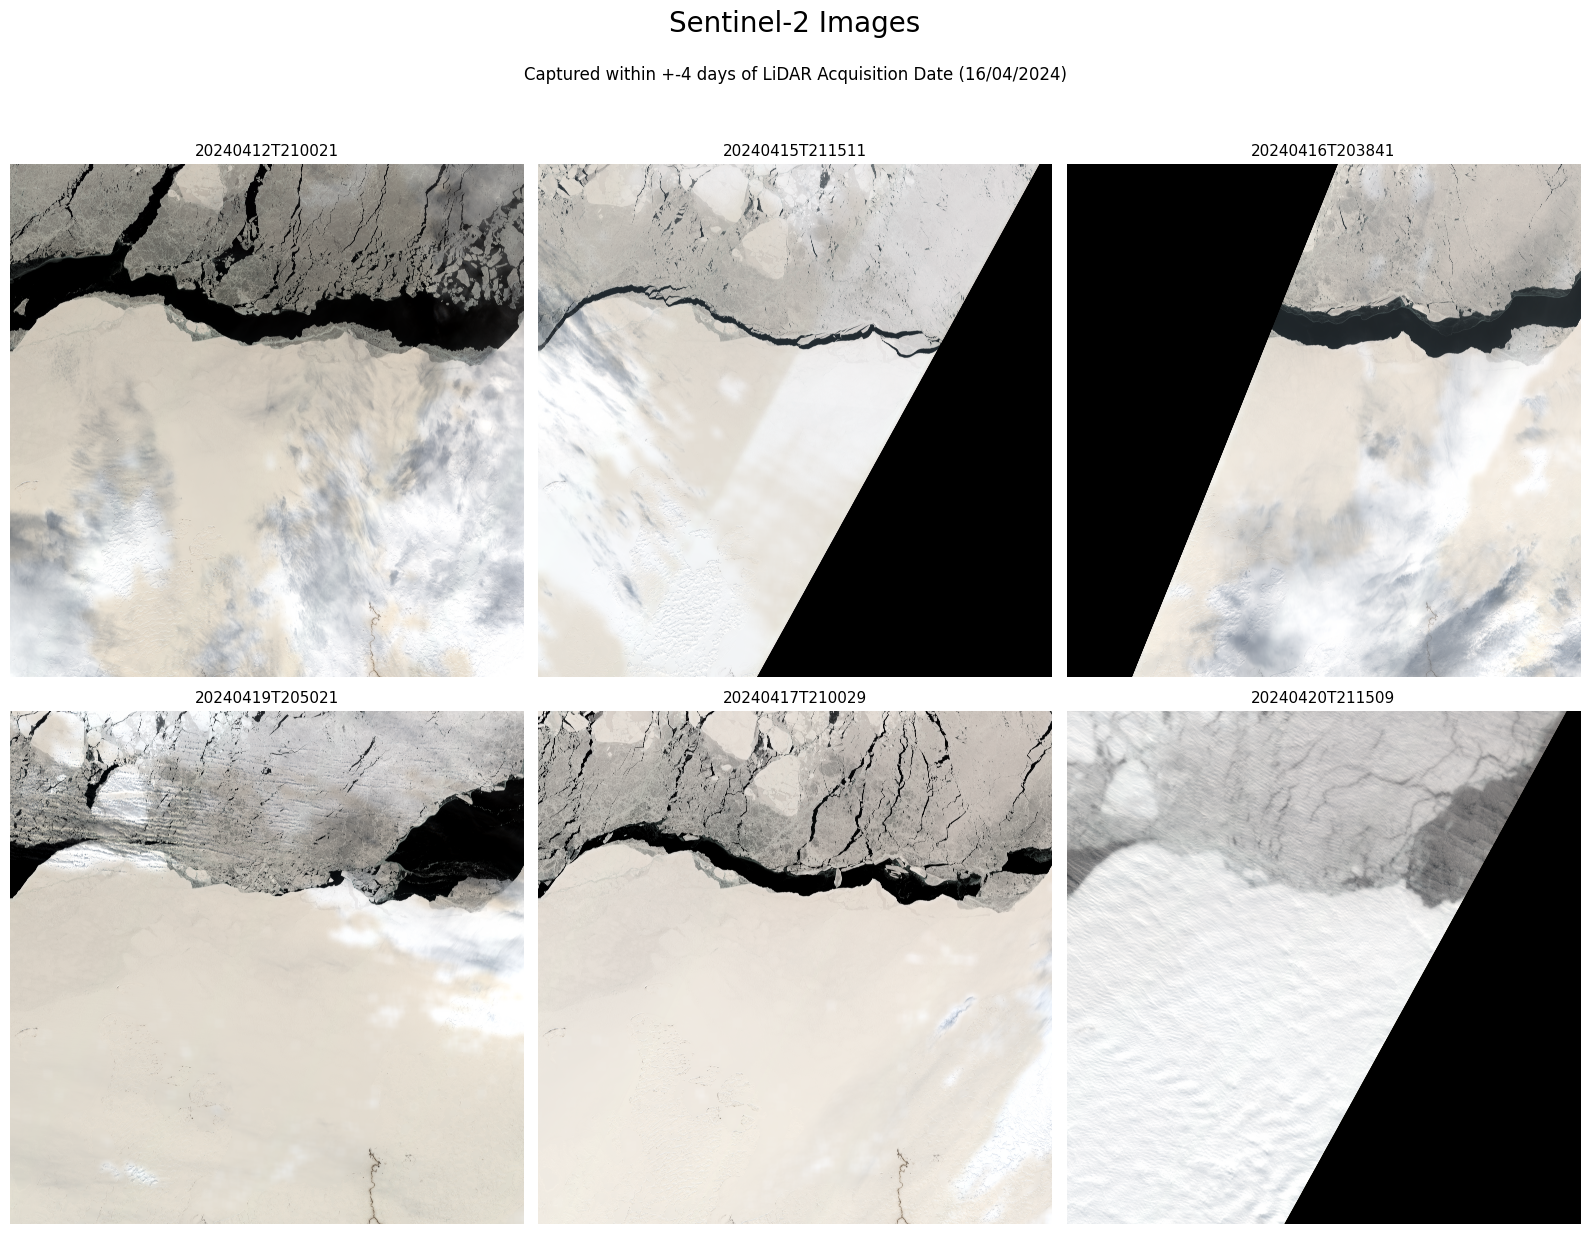

In [8]:
# Visualize the six images of interest

sentinel_granule_dirs = [
    "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240412T210021_N0510_R100_T08WNC_20240413T020550.SAFE/S2A_MSIL2A_20240412T210021_N0510_R100_T08WNC_20240413T020550.SAFE/GRANULE",
    "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240415T211511_N0510_R143_T08WNC_20240416T013744.SAFE/S2A_MSIL2A_20240415T211511_N0510_R143_T08WNC_20240416T013744.SAFE/GRANULE",
    "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240416T203841_N0510_R014_T08WNC_20240417T023953.SAFE/S2A_MSIL2A_20240416T203841_N0510_R014_T08WNC_20240417T023953.SAFE/GRANULE",
    "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240419T205021_N0510_R057_T08WNC_20240420T014550.SAFE/S2A_MSIL2A_20240419T205021_N0510_R057_T08WNC_20240420T014550.SAFE/GRANULE",
    "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2B_MSIL2A_20240417T210029_N0510_R100_T08WNC_20240418T003922.SAFE/S2B_MSIL2A_20240417T210029_N0510_R100_T08WNC_20240418T003922.SAFE/GRANULE",
    "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2B_MSIL2A_20240420T211509_N0510_R143_T08WNC_20240420T230422.SAFE/S2B_MSIL2A_20240420T211509_N0510_R143_T08WNC_20240420T230422.SAFE/GRANULE"
]

main_title = "Sentinel-2 Images"
sub_title  = "Captured within +-4 days of LiDAR Acquisition Date (16/04/2024)"

def find_img_data_r10m(granule_root):
    """
    Given a path ending in .../SAFE/GRANULE, find the IMG_DATA/R10m directory
    inside the single granule subfolder. Returns the path.

    """
    granule_subdirs = [
        os.path.join(granule_root, d)
        for d in os.listdir(granule_root)
        if os.path.isdir(os.path.join(granule_root, d))
    ]
    for g in granule_subdirs:
        candidate = os.path.join(g, "IMG_DATA", "R10m")
        if os.path.isdir(candidate):
            return candidate


def load_rgb_r10m(img_data_r10m_dir):
    """
    Load B04 (red), B03 (green), B02 (blue) as float32 arrays and stack into RGB.
    """
    def find_band(filename_part):
        matches = [os.path.join(img_data_r10m_dir, f)
                   for f in os.listdir(img_data_r10m_dir)
                   if filename_part in f]
        return matches[0]

    b04_path = find_band("B04_10m.jp2")
    b03_path = find_band("B03_10m.jp2")
    b02_path = find_band("B02_10m.jp2")

    with rasterio.open(b04_path) as r:
        b04 = r.read(1).astype(np.float32)
    with rasterio.open(b03_path) as g:
        b03 = g.read(1).astype(np.float32)
    with rasterio.open(b02_path) as b:
        b02 = b.read(1).astype(np.float32)

    rgb = np.stack([b04, b03, b02], axis=-1)
    return rgb


def percentile_normalize(img, lower=2, upper=98):
    """
    Robust percentile-based normalization to [0,1] per channel.
    Handles edge cases where p_high == p_low.
    """
    img = img.copy()
    out = np.zeros_like(img, dtype=np.float32)
    for i in range(img.shape[-1]):
        p_low, p_high = np.percentile(img[..., i], (lower, upper))
        if p_high <= p_low:
            vmin, vmax = img[..., i].min(), img[..., i].max()
        else:
            vmin, vmax = p_low, p_high
        denom = (vmax - vmin) if (vmax - vmin) != 0 else 1.0
        out[..., i] = np.clip((img[..., i] - vmin) / denom, 0, 1)
    return out

# Load all six RGB composites
rgb_images = []
for granule_dir in sentinel_granule_dirs:
    img_data_r10m = find_img_data_r10m(granule_dir)
    rgb = load_rgb_r10m(img_data_r10m)
    rgb_norm = percentile_normalize(rgb, lower=2, upper=98)
    rgb_images.append(rgb_norm)

# Plot 2×3 tiled figure
fig, axes = plt.subplots(2, 3, figsize=(16, 13))
fig.suptitle(main_title, fontsize=20, y=0.98)
fig.text(0.5, 0.93, sub_title, ha="center", va="center", fontsize=12)

for idx, ax in enumerate(axes.ravel()):
    ax.imshow(rgb_images[idx])
    ax.set_title(sentinel_granule_dirs[idx].split("/")[-2].split("_")[-5], fontsize=11)
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [ ]:
# Config

patch_size = 256  
stride = 128      
valid_threshold = 0.7

lidar_dir = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_lidar"
out_lidar_dir = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/input_data/tuk_lidar_patches"
out_s2_dir = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/input_data/s2_patches_tuk"
os.makedirs(out_lidar_dir, exist_ok=True)
os.makedirs(out_s2_dir, exist_ok=True)

# Identify sentinel-2 images of interest (order best to worst based on manual inspection)
sentinel_granule_dirs = [
    "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240416T203841_N0510_R014_T08WNC_20240417T023953.SAFE/S2A_MSIL2A_20240416T203841_N0510_R014_T08WNC_20240417T023953.SAFE/GRANULE",
    "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240416T203841_N0510_R014_T08WNC_20240417T023953.SAFE/S2A_MSIL2A_20240416T203841_N0510_R014_T08WNC_20240417T023953.SAFE/GRANULE",
    "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240419T205021_N0510_R057_T08WNC_20240420T014550.SAFE/S2A_MSIL2A_20240419T205021_N0510_R057_T08WNC_20240420T014550.SAFE/GRANULE",
    "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240415T211511_N0510_R143_T08WNC_20240416T013744.SAFE/S2A_MSIL2A_20240415T211511_N0510_R143_T08WNC_20240416T013744.SAFE/GRANULE",
    "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/raw_data/tuk_sentinel_downloads/S2A_MSIL2A_20240412T210021_N0510_R100_T08WNC_20240413T020550.SAFE/S2A_MSIL2A_20240412T210021_N0510_R100_T08WNC_20240413T020550.SAFE/GRANULE"
    ]

sentinel_meta_jsons = [g.replace(".SAFE/GRANULE", "_metadata.json") for g in sentinel_granule_dirs]


In [19]:
# Merge LiDAR files

def merge_lidar_files(lidar_files):
    src_files = [rasterio.open(fp) for fp in lidar_files]
    mosaic, mosaic_transform = merge(src_files,nodata=-9999,dtype='float32')
    lidar_meta = src_files[0].meta.copy()
    lidar_meta.update({
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": mosaic_transform,
        "nodata": -9999
    })
    for src in src_files:
        src.close()
    return mosaic[0], mosaic_transform, lidar_meta

lidar_files = glob(os.path.join(lidar_dir, "*.tif"))
lidar_array, lidar_transform, lidar_meta = merge_lidar_files(lidar_files)
lidar_crs = lidar_meta["crs"]
s2_patch_size = patch_size // 10
# Replace -9999 with NaN
lidar_array = np.where(lidar_array == -9999, np.nan, lidar_array)

Text(0.5, 1.0, 'Merged LiDAR Elevation')

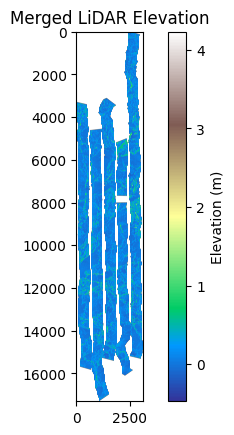

In [ ]:
# Inspect merged lidar array

plt.imshow(lidar_array, cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title('Merged LiDAR Elevation')

In [ ]:
# Stack S2 Bands
def stack_sentinel_bands(safe_granule_path):
    band_files = {}
    for band in ["B02", "B03", "B04", "B08"]:
        pattern = os.path.join(safe_granule_path, "**", f"*_{band}_10m.jp2")
        matches = glob(pattern, recursive=True)
        if not matches:
            raise FileNotFoundError(f"Could not find band {band} in {safe_granule_path}.")
        band_files[band] = matches[0]

    band_stack = []
    meta = None
    for band in ["B04", "B03", "B02", "B08"]:
        with rasterio.open(band_files[band]) as src:
            band_stack.append(src.read(1))
            if meta is None:
                meta = src.meta.copy()
    stacked = np.stack(band_stack, axis=0)  
    return stacked, meta

def load_json_safe(path):
    if path is None or not os.path.exists(path):
        return None
    with open(path, "r") as f:
        return json.load(f)

sentinel_products = []
for i, gdir in enumerate(sentinel_granule_dirs):
    stack, meta = stack_sentinel_bands(gdir)
    sentinel_products.append({
        "stack": stack,
        "meta": meta,
        "transform": meta["transform"],
        "crs": meta["crs"],
        "attrs": load_json_safe(sentinel_meta_jsons[i])
    })
    
# Extract patches by region or full-scan (test)
def extract_lidar_multi_s2_by_region(
    lidar_array, lidar_transform, lidar_crs,
    sentinel_products,
    patch_size, s2_patch_size,
    out_lidar_dir, out_s2_dir,
    region_patch_indices,
    start_idx=0,
    test=False):

    lidar_array = np.where(lidar_array == -9999, np.nan, lidar_array)
    count = 0

    if test:
        H, W = lidar_array.shape
        positions = [(x, y)
                     for y in range(0, H - patch_size + 1, patch_size)
                     for x in range(0, W - patch_size + 1, patch_size)]
        region_iter = [(None, positions)]
    else:
        region_iter = list(enumerate(region_patch_indices))

    for region_id, patch_list in region_iter:
        for x, y in patch_list:
            lid_win = Window(x, y, patch_size, patch_size)
            lid_bounds = rasterio.windows.bounds(lid_win, lidar_transform)
            lid_patch_raw = lidar_array[y:y+patch_size, x:x+patch_size]
            valid_mask = ~np.isnan(lid_patch_raw)
            if valid_mask.mean() < valid_threshold:
                continue

            lid_patch = np.nan_to_num(lid_patch_raw, nan=0.0)
            lid_mask = valid_mask.astype(np.uint8)
            lidar_patch = np.stack([lid_patch, lid_mask], axis=0)

            s2_patches, s2_transforms, ok = [], [], True
            for prod in sentinel_products:
                try:
                    s2_bounds = transform_bounds(lidar_crs, prod["crs"], *lid_bounds, densify_pts=21)
                    s2_window = from_bounds(*s2_bounds, prod["transform"])
                    s2_row = int(s2_window.row_off)
                    s2_col = int(s2_window.col_off)
                    s2_patch = prod["stack"][:, s2_row:s2_row + s2_patch_size, s2_col:s2_col + s2_patch_size]
                    if s2_patch.shape[1:] != (s2_patch_size, s2_patch_size):
                        ok = False
                        break
                    s2_patches.append(s2_patch)
                    s2_transforms.append(rasterio.windows.transform(s2_window, prod["transform"]))
                except Exception:
                    ok = False
                    break

            if not ok or len(s2_patches) != len(sentinel_products):
                continue

            patch_id = f"{start_idx + count:05d}"
            lid_out = os.path.join(out_lidar_dir, f"lidar_patch_{patch_id}.tif")
            lid_meta = {
                "driver": "GTiff",
                "height": patch_size,
                "width": patch_size,
                "count": 2,
                "dtype": lidar_patch.dtype,
                "crs": lidar_crs,
                "transform": rasterio.windows.transform(lid_win, lidar_transform)
            }
            with rasterio.open(lid_out, "w", **lid_meta) as dst:
                dst.write(lidar_patch)

            patch_dir = os.path.join(out_s2_dir, f"s2_patch_{patch_id}")
            os.makedirs(patch_dir, exist_ok=True)
            attrs_list = []

            for i, (prod, s2_patch, s2_tr) in enumerate(zip(sentinel_products, s2_patches, s2_transforms)):
                s2_meta = prod["meta"].copy()
                s2_meta.update({
                    "count": 4,
                    "height": s2_patch_size,
                    "width": s2_patch_size,
                    "transform": s2_tr
                })
                s2_path = os.path.join(patch_dir, f"t{i}.tif")
                with rasterio.open(s2_path, "w", **s2_meta) as dst:
                    dst.write(s2_patch)

                record = None
                if prod.get("attrs"):
                    a = prod["attrs"]
                    record = {
                        "product_id": a.get("product_id") or a.get("productId"),
                        "product_name": a.get("product_name") or a.get("productName"),
                        "acquisition_date": a.get("acquisition_date"),
                        "cloud_cover": a.get("cloud_cover"),
                        "sun_zenith_mean": a.get("sun_zenith_mean"),
                        "sun_azimuth_mean": a.get("sun_azimuth_mean"),
                        "view_zenith_mean": a.get("view_zenith_mean"),
                        "view_azimuth_mean": a.get("view_azimuth_mean"),
                    }
                attrs_list.append(record)

            with open(os.path.join(patch_dir, "attrs.json"), "w") as jf:
                json.dump(attrs_list, jf, indent=2)

            if not test:
                with open(os.path.join(patch_dir, "region.json"), "w") as jf:
                    json.dump({"region_id": region_id}, jf)

            count += 1
            if count // 500 > 0 and count % 500 == 0:
                print(f"Processed {count} patches...")

    return count

# Execution
total = extract_lidar_multi_s2_by_region(
    lidar_array=lidar_array,
    lidar_transform=lidar_transform,
    lidar_crs=lidar_crs,
    sentinel_products=sentinel_products,
    patch_size=patch_size,
    s2_patch_size=s2_patch_size,
    out_lidar_dir=out_lidar_dir,
    out_s2_dir=out_s2_dir,
    region_patch_indices=None,  # ignored when test=True
    start_idx=0,
    test=True  # set False to use regions
)

if True:  # match the flag above
    print(f"Extracted {total} LiDAR patches in full-scan test mode.")
else:
    print(f"Extracted {total} LiDAR patches across {num_regions} regions.")


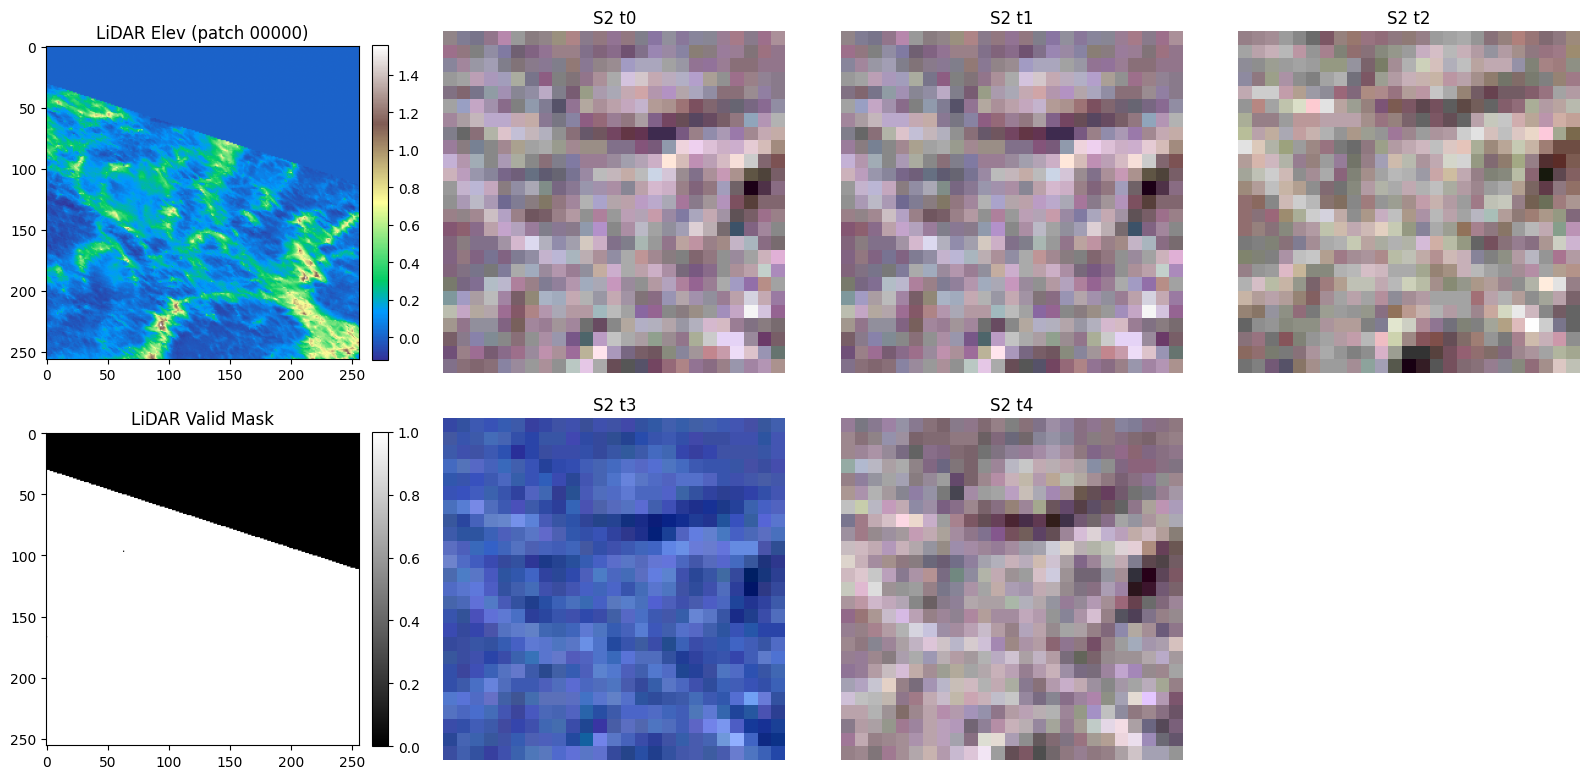

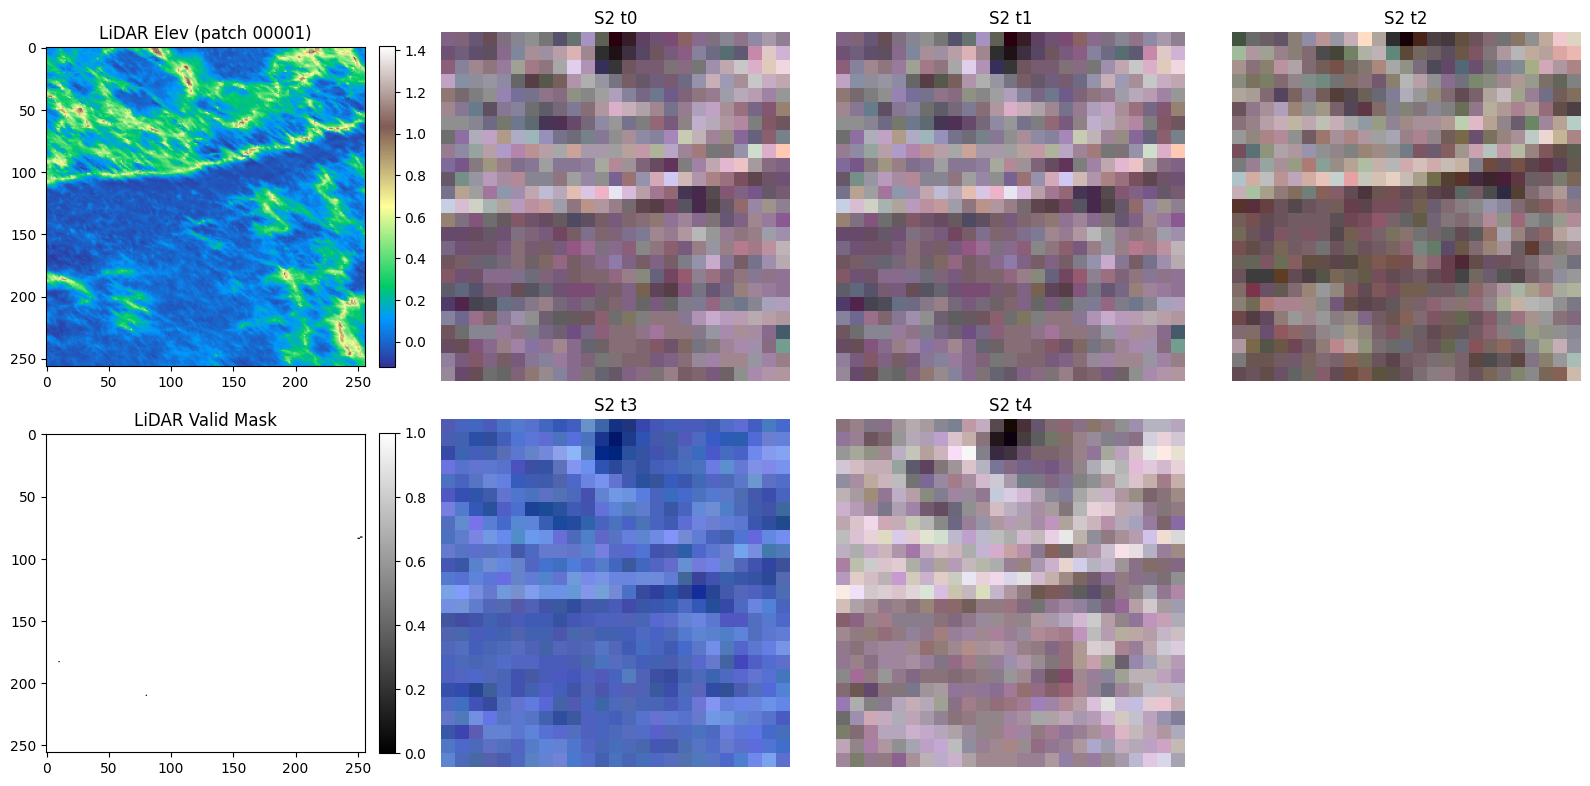

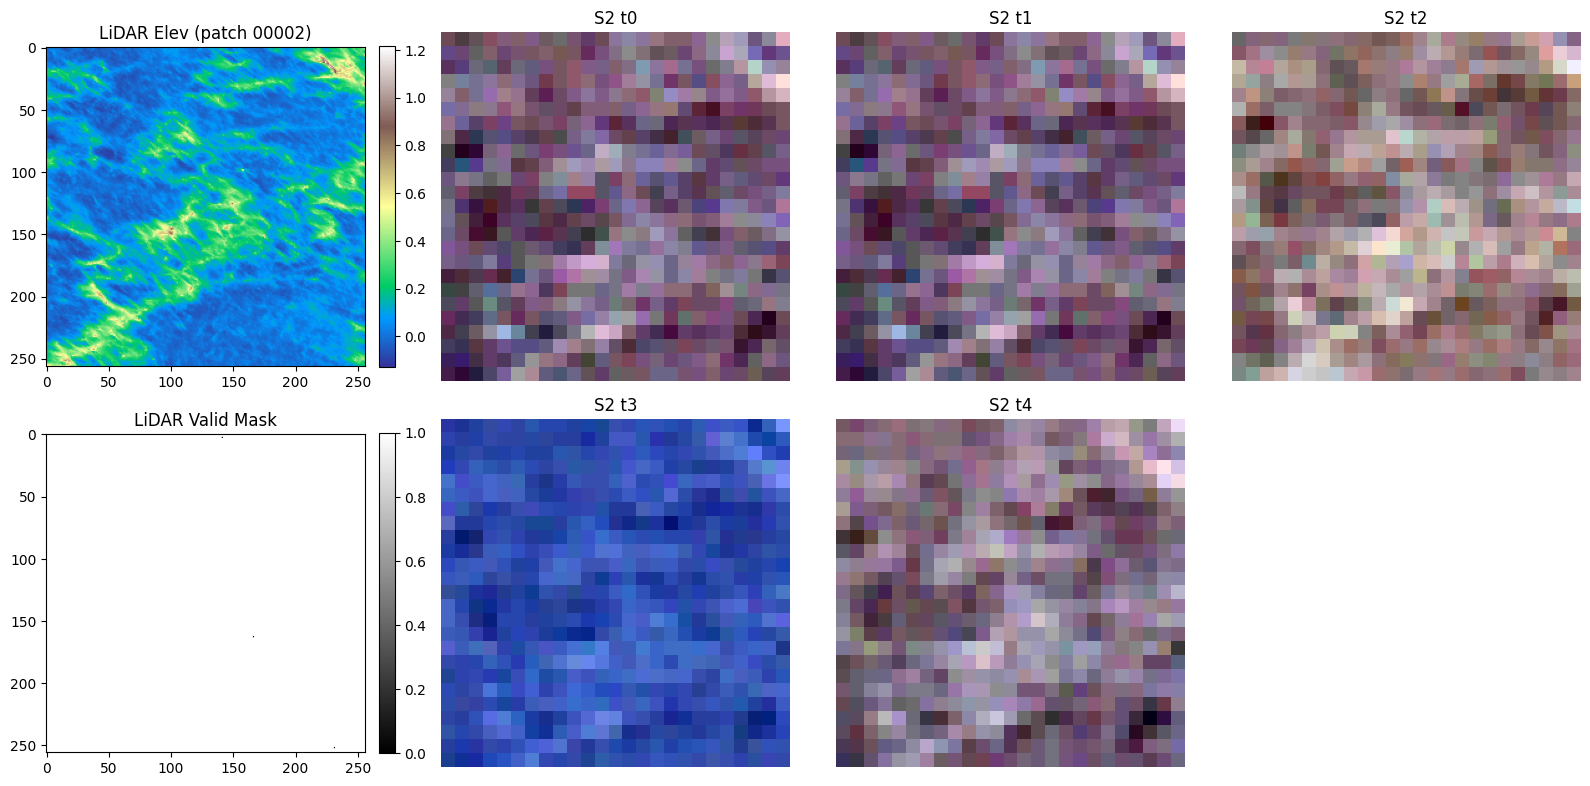

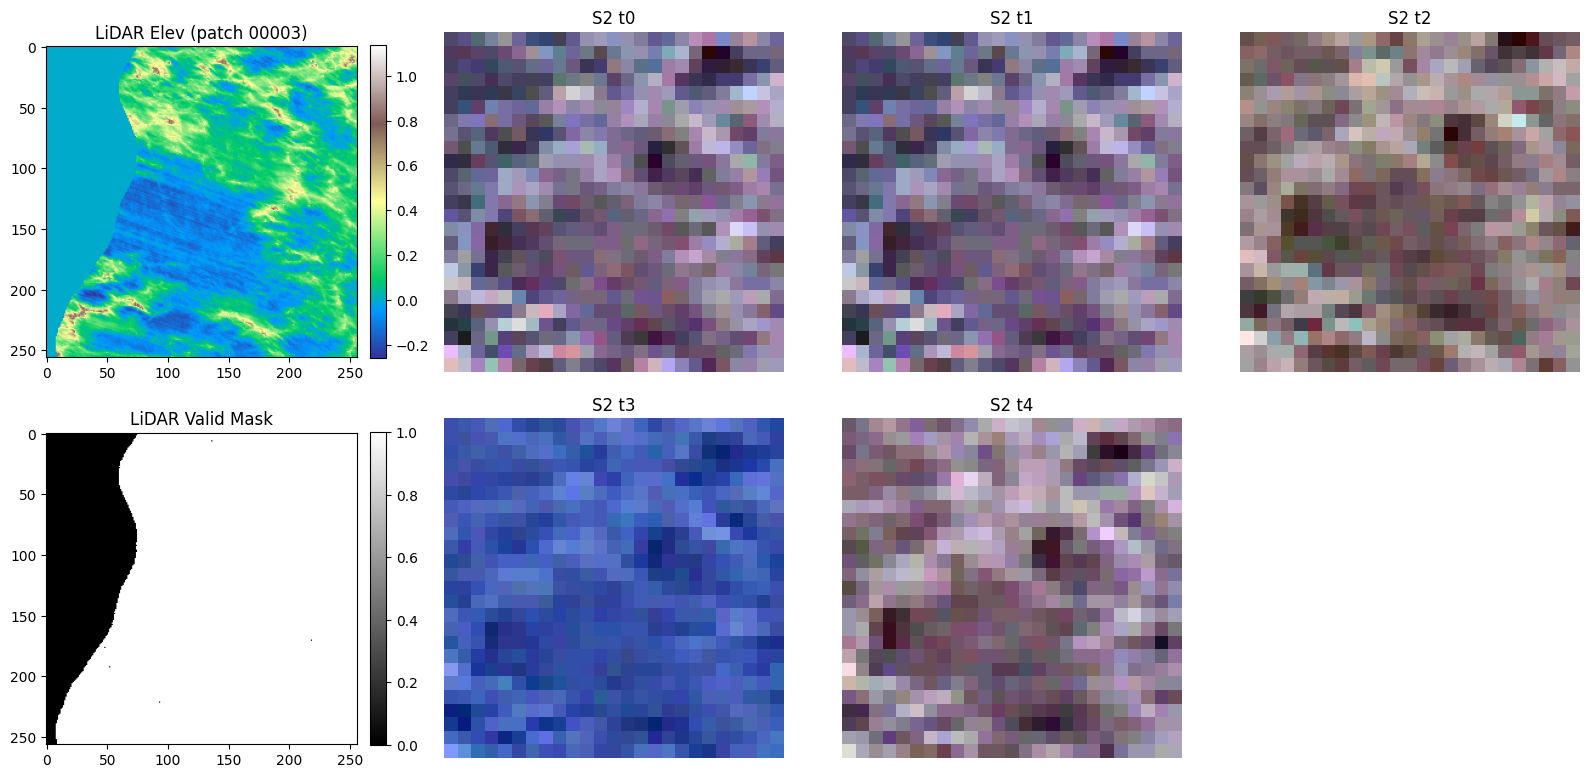

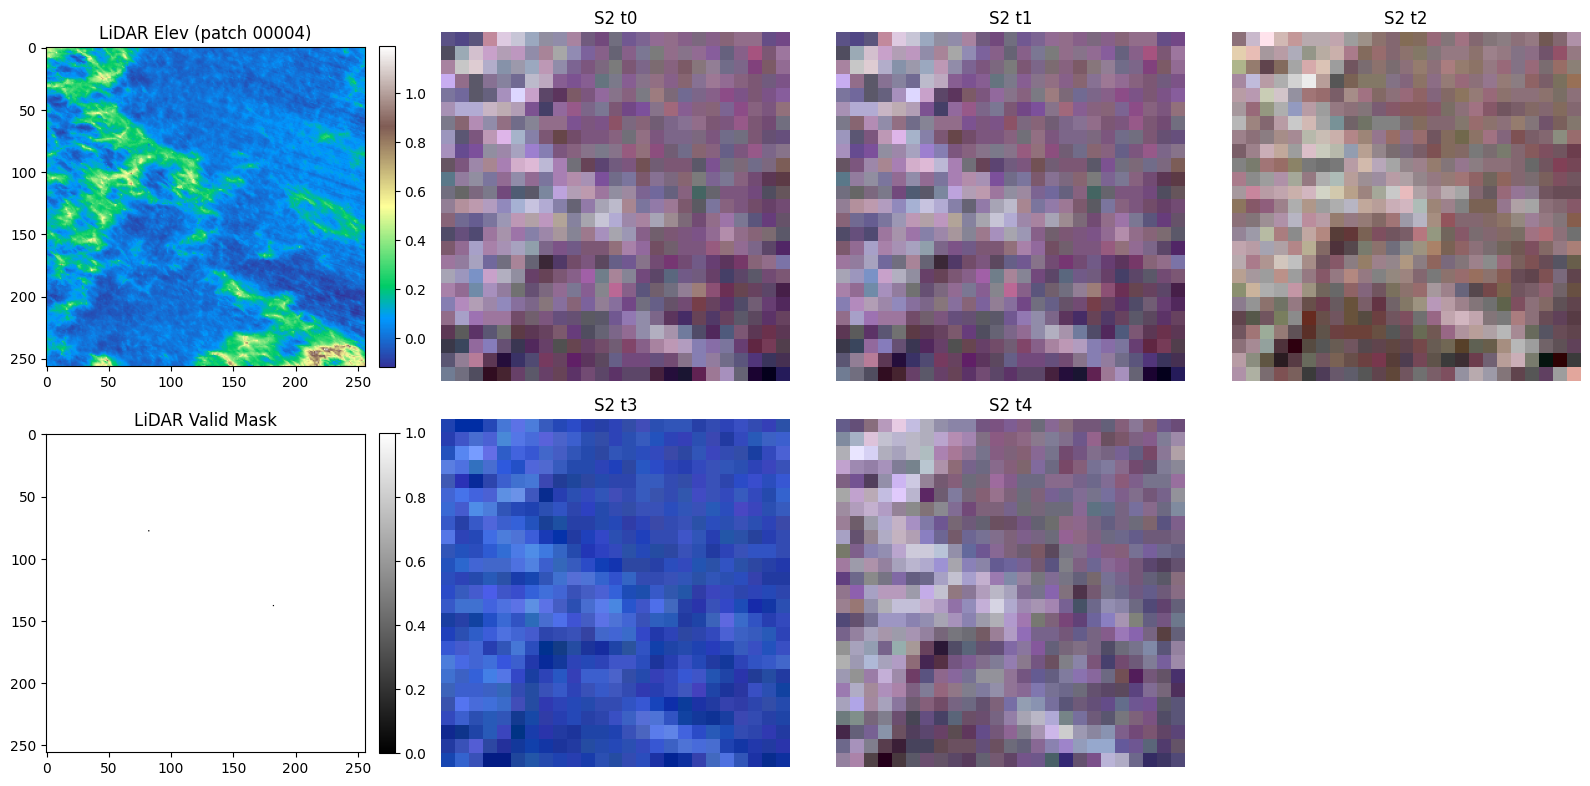

In [23]:
# Visualize patches

def normalize_01(img):
    img = img.astype(np.float32)
    mn, mx = np.nanmin(img), np.nanmax(img)
    if mx <= mn:
        return np.zeros_like(img)
    return (img - mn) / (mx - mn)

def show_group(patch_id, out_lidar_dir, out_s2_dir):
    lid_path = os.path.join(out_lidar_dir, f"lidar_patch_{patch_id}.tif")
    s2_dir  = os.path.join(out_s2_dir, f"s2_patch_{patch_id}")

    with rasterio.open(lid_path) as src:
        lidar_elev = src.read(1)
        lidar_mask = src.read(2)

    s2_imgs = []
    for i in range(5):
        s2_path = os.path.join(s2_dir, f"t{i}.tif")
        with rasterio.open(s2_path) as src:
            rgb = src.read([1, 2, 3])
        rgb = np.moveaxis(rgb, 0, -1)
        s2_imgs.append(normalize_01(rgb))

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    ax = axes.ravel()

    im0 = ax[0].imshow(lidar_elev, cmap="terrain")
    ax[0].set_title(f"LiDAR Elev (patch {patch_id})")
    plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

    im1 = ax[4].imshow(lidar_mask, cmap="gray")
    ax[4].set_title("LiDAR Valid Mask")
    plt.colorbar(im1, ax=ax[4], fraction=0.046, pad=0.04)

    titles = [f"S2 t{i}" for i in range(5)]
    for i in range(3):
        ax[1 + i].imshow(s2_imgs[i])
        ax[1 + i].set_title(titles[i])
        ax[1 + i].axis("off")

    for i in range(3, 5):
        ax[5 + (i - 3)].imshow(s2_imgs[i])
        ax[5 + (i - 3)].set_title(titles[i])
        ax[5 + (i - 3)].axis("off")

    for a in ax:
        if not hasattr(a.images, "__len__") or len(a.images) == 0:
            a.axis("off")

    plt.tight_layout()
    plt.show()

# Visualize first few samples
sample_lidar = sorted(glob(os.path.join(out_lidar_dir, "lidar_patch_*.tif")))[:5]
for p in sample_lidar:
    pid = os.path.splitext(os.path.basename(p))[0].split("_")[-1]
    show_group(pid, out_lidar_dir, out_s2_dir)